In [21]:
import geopandas as gpd
from geodatasets import get_path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from shapely.geometry import Point

import pandas as pd
import numpy as np

import glob
import os

In [22]:
# Load privately owned public spaces and format the data
spaces = pd.read_csv("Privately_Owned_Public_Spaces__POPS__20250310.csv")
spaces = spaces.dropna(subset=["Latitude", "Longitude", "Year_Completed"])
spaces["ZIP Code"] = spaces['Building_Address_With_Zip_Code'].str.split().str[-1]
# remove 0 values
spaces = spaces[spaces["Year_Completed"] != 0]

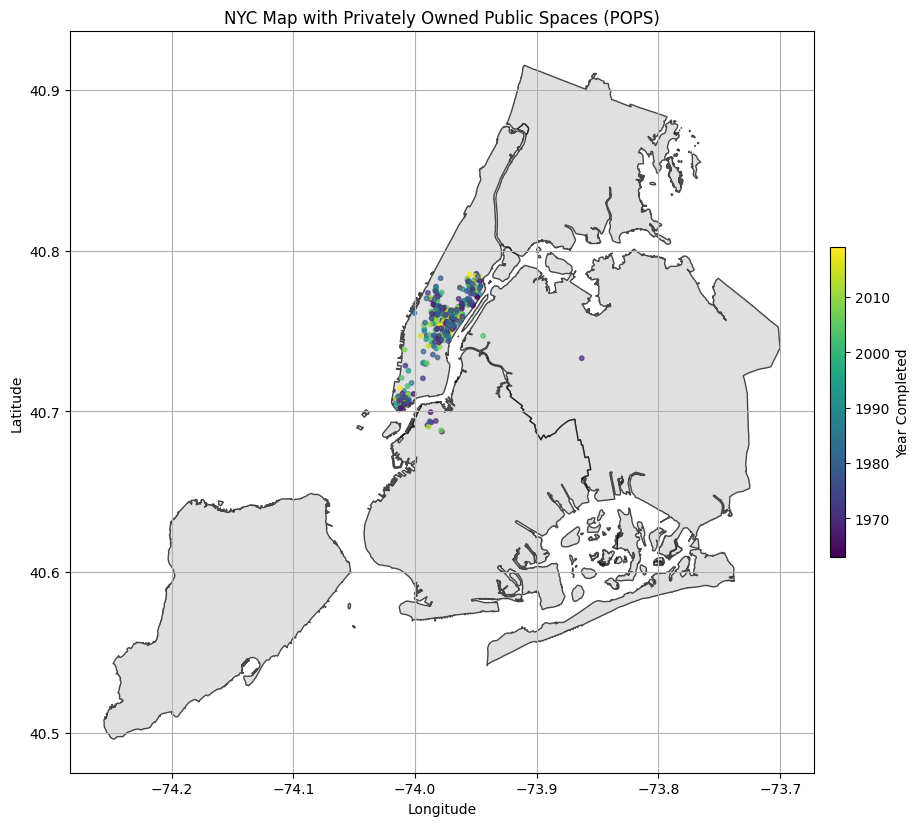

In [23]:
# Create GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(spaces["Longitude"], spaces["Latitude"]), 
    crs="EPSG:4326"
)

# Read NYC map
nyc_map = gpd.read_file(get_path("nybb")).to_crs(epsg=4326)

# Define colormap and normalization
cmap = plt.cm.viridis  # Use the viridis colormap
norm = mcolors.Normalize(vmin=spaces["Year_Completed"].min(), vmax=spaces["Year_Completed"].max())

# Plot the map
fig, ax = plt.subplots(figsize=(10, 10))
nyc_map.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.7)

# Plot points with assigned colors
gdf_points.plot(ax=ax, cmap=cmap, markersize=10, alpha=0.7)

# Create a colorbar (sidebar)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Year Completed")

# Titles and labels
plt.title("NYC Map with Privately Owned Public Spaces (POPS)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

plt.show()

In [24]:
# Load all NYC SAFMR data
input_files_path = os.path.join("safmr_filtered", "*.csv")
input_files = glob.glob(input_files_path)

yearly_zip_code_rents = {}

for file in input_files:
    df = pd.read_csv(file)
    df_filtered = df[['ZIP Code', 'SAFMR 0BR - 90% Payment Standard']]

    df_filtered['ZIP Code'] = df_filtered['ZIP Code'].astype(str)
    df_filtered['SAFMR 0BR - 90% Payment Standard'] = (
        df_filtered['SAFMR 0BR - 90% Payment Standard']
        .replace({'\$': '', ',': ''}, regex=True)
        .astype(float)
    )
        
    zip_values = dict(zip(df_filtered['ZIP Code'], df_filtered['SAFMR 0BR - 90% Payment Standard']))

    year = os.path.basename(file).split('.')[0][2:]  # Extract year from filename
    yearly_zip_code_rents[year] = zip_values

<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
/var/folders/mc/pwtbg_1x0bq90w0qhn4rxs1h0000gn/T/ipykernel_15356/2746835979.py:14: SyntaxWarning: invalid escape sequence '\$'
  .replace({'\$': '', ',': ''}, regex=True)
/var/folders/mc/pwtbg_1x0bq90w0qhn4rxs1h0000gn/T/ipykernel_15356/2746835979.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['ZIP Code'] = df_filtered['ZIP Code'].astype(str)
/var/folders/mc/pwtbg_1x0bq90w0qhn4rxs1h0000gn/T/ipykernel_15356/2746835979.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

In [25]:
yearly_zip_code_rents.keys()
zip_values = yearly_zip_code_rents['2025']
zip_values

{'12007': 981.0,
 '12008': 981.0,
 '12009': 990.0,
 '12010': 819.0,
 '12018': 1071.0,
 '12019': 999.0,
 '12020': 1197.0,
 '12022': 999.0,
 '12023': 828.0,
 '12024': 990.0,
 '12025': 819.0,
 '12027': 1413.0,
 '12028': 882.0,
 '12031': 819.0,
 '12033': 999.0,
 '12035': 846.0,
 '12036': 819.0,
 '12040': 954.0,
 '12041': 900.0,
 '12043': 819.0,
 '12045': 1062.0,
 '12046': 891.0,
 '12047': 981.0,
 '12052': 1026.0,
 '12053': 819.0,
 '12054': 1188.0,
 '12055': 981.0,
 '12056': 972.0,
 '12057': 900.0,
 '12059': 828.0,
 '12061': 1242.0,
 '12062': 891.0,
 '12063': 1008.0,
 '12064': 819.0,
 '12065': 1026.0,
 '12066': 981.0,
 '12067': 819.0,
 '12071': 819.0,
 '12073': 819.0,
 '12074': 1017.0,
 '12076': 855.0,
 '12077': 1098.0,
 '12082': 1026.0,
 '12083': 846.0,
 '12084': 1179.0,
 '12085': 819.0,
 '12086': 819.0,
 '12087': 909.0,
 '12089': 936.0,
 '12090': 819.0,
 '12092': 828.0,
 '12093': 819.0,
 '12094': 882.0,
 '12107': 981.0,
 '12110': 1134.0,
 '12118': 846.0,
 '12120': 819.0,
 '12121': 855.0,


In [26]:
gdf = gpd.read_file('zipcode/geo_export_b459f634-6bcb-46d7-ade3-b0ef95b76ebc.shp')
gdf['label'] = gdf['label'].str.split(',').str[0]

In [27]:
gdf['value'] = gdf['label'].map(zip_values)
gdf = gdf.dropna(subset=['value'])
gdf

,modzcta,label,zcta,pop_est,geometry,value
0,10001,10001,"10001, 10119, 10199",23072.0,"POLYGON ((-73.98774 40.74407, -73.98819 40.743...",2772.0
1,10002,10002,10002,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",1935.0
2,10003,10003,10003,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",3015.0
3,10026,10026,10026,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",1953.0
4,10004,10004,10004,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",2907.0
...,...,...,...,...,...,...
172,11433,11433,"11433, 11451",36489.0,"POLYGON ((-73.79437 40.68691, -73.79478 40.687...",1935.0
173,11434,11434,"11430, 11434",65989.0,"POLYGON ((-73.75461 40.6472, -73.7538 40.6467,...",1935.0
174,11435,11435,11435,59296.0,"POLYGON ((-73.80577 40.68293, -73.80606 40.683...",1953.0
175,11694,11694,11694,21354.0,"POLYGON ((-73.86496 40.56663, -73.86558 40.567...",1935.0


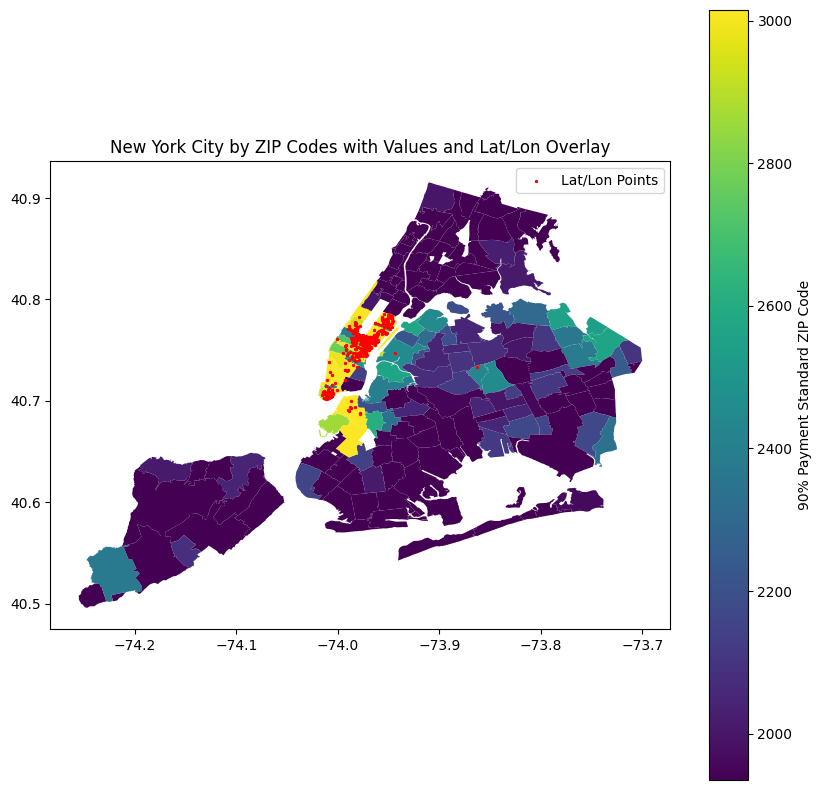

In [28]:
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf['value'].min(), vmax=gdf['value'].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(ax=ax, column='value', cmap=cmap, legend=True, legend_kwds={'label': "90% Payment Standard ZIP Code", 'orientation': "vertical"})

geometry = [Point(lon, lat) for lon, lat in zip(spaces['Longitude'], spaces['Latitude'])]
lat_lon_gdf = gpd.GeoDataFrame(spaces, geometry=geometry)

# Plot lat/long data points
lat_lon_gdf.plot(ax=ax, color='red', markersize=2, label="Lat/Lon Points")


ax.set_title("New York City by ZIP Codes with Values and Lat/Lon Overlay")
ax.legend()

plt.show()

In [29]:
len(zip_values.keys())

1540

In [30]:
pop_zip_codes, counts = np.unique(spaces['ZIP Code'], return_counts=True)
zip_code_counts = dict(zip(pop_zip_codes, counts))
print(zip_code_counts)

{'10001': np.int64(4), '10002': np.int64(1), '10003': np.int64(6), '10004': np.int64(12), '10005': np.int64(14), '10006': np.int64(8), '10007': np.int64(4), '10010': np.int64(5), '10011': np.int64(1), '10013': np.int64(3), '10014': np.int64(2), '10016': np.int64(34), '10017': np.int64(30), '10018': np.int64(4), '10019': np.int64(36), '10020': np.int64(1), '10021': np.int64(15), '10022': np.int64(47), '10023': np.int64(17), '10024': np.int64(1), '10028': np.int64(14), '10036': np.int64(16), '10038': np.int64(12), '10041': np.int64(1), '10055': np.int64(1), '10065': np.int64(12), '10075': np.int64(8), '10105': np.int64(1), '10106': np.int64(1), '10119': np.int64(1), '10121': np.int64(1), '10128': np.int64(22), '10153': np.int64(1), '10154': np.int64(1), '10155': np.int64(1), '10167': np.int64(1), '10171': np.int64(1), '10178': np.int64(1), '10179': np.int64(1), '11101': np.int64(1), '11201': np.int64(6), '11217': np.int64(2), '11374': np.int64(1)}


In [31]:
# section the data with those that do not have pops, and those that do
for year, zip_code_rents in yearly_zip_code_rents.items():
    for zip_code, value in zip_values.items():
        if zip_code not in zip_code_counts:
            zip_code_counts[zip_code] = 0

In [32]:
# get the average rent increase for zip codes that do have POPS, and those that do not
zip_code_df = pd.DataFrame(list(zip_code_counts.items()), columns=['ZIP Code', 'Count'])

# Compute rent increase for each ZIP code over the years
rent_increases = {}

for year, zip_code_rents in yearly_zip_code_rents.items():
    for zip_code, rent in zip_code_rents.items():
        if zip_code not in rent_increases:
            rent_increases[zip_code] = []
        rent_increases[zip_code].append(rent)

# Calculate the average rent increase for each ZIP code
avg_rent_increases = {}
for zip_code, rents in rent_increases.items():
    # get percent increase from the first year to the last year
    avg_rent_increases[zip_code] = {
        "rent_increase": rents[-1] - rents[0],
        "rent": rents[-1],
        "pops_count": zip_code_counts.get(zip_code, 0)
    }

# Convert dictionary to DataFrame
avg_rent_increase_df = pd.DataFrame.from_dict(avg_rent_increases, orient='index')

# Reset index and rename columns
avg_rent_increase_df.reset_index(inplace=True)
avg_rent_increase_df.rename(columns={'index': 'ZIP Code'}, inplace=True)

display(avg_rent_increase_df)

,ZIP Code,rent_increase,rent,pops_count
0,12007,36.0,918.0,0
1,12008,9.0,918.0,0
2,12009,18.0,954.0,0
3,12010,63.0,792.0,0
4,12018,45.0,990.0,0
...,...,...,...,...
1540,12414,450.0,1152.0,0
1541,12434,-27.0,792.0,0
1542,14260,-243.0,873.0,0
1543,10521,-558.0,1485.0,0


In [33]:
non_pops = avg_rent_increase_df[avg_rent_increase_df['pops_count'] == 0]
pops = avg_rent_increase_df[avg_rent_increase_df['pops_count'] != 0]

print("Rent Net Increase | Non Pops:", non_pops['rent_increase'].mean(), "| Pops:", pops['rent_increase'].mean())
print("Average Rent | Non Pops:", non_pops['rent'].mean(), "| Pops:", pops['rent'].mean())

Rent Net Increase | Non Pops: 118.21637816245007 | Pops: 276.90697674418607
Average Rent | Non Pops: 1274.662450066578 | Pops: 2908.4651162790697


In [34]:
df = pd.read_csv(os.path.join('racial_data', 'data.csv'))
df["ZIP Code"] = df["NAME"].str.split(" ").str[-1]
df["perc_white"] = df["P8_003N"] / df["P8_001N"]
df["perc_black"] = df["P8_004N"] / df["P8_001N"]


In [35]:
racial_group = 'perc_white'
gdf_with_race = gdf.merge(df[['ZIP Code', racial_group]], left_on='label', right_on='ZIP Code', how='left')
gdf_with_race

,modzcta,label,zcta,pop_est,geometry,value,ZIP Code,perc_white
0,10001,10001,"10001, 10119, 10199",23072.0,"POLYGON ((-73.98774 40.74407, -73.98819 40.743...",2772.0,10001,0.533822
1,10002,10002,10002,74993.0,"POLYGON ((-73.9975 40.71407, -73.99709 40.7146...",1935.0,10002,0.278827
2,10003,10003,10003,54682.0,"POLYGON ((-73.98864 40.72293, -73.98876 40.722...",3015.0,10003,0.694442
3,10026,10026,10026,39363.0,"MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...",1953.0,10026,0.250589
4,10004,10004,10004,3028.0,"MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...",2907.0,10004,0.594588
...,...,...,...,...,...,...,...,...
172,11433,11433,"11433, 11451",36489.0,"POLYGON ((-73.79437 40.68691, -73.79478 40.687...",1935.0,11433,0.029382
173,11434,11434,"11430, 11434",65989.0,"POLYGON ((-73.75461 40.6472, -73.7538 40.6467,...",1935.0,11434,0.022370
174,11435,11435,11435,59296.0,"POLYGON ((-73.80577 40.68293, -73.80606 40.683...",1953.0,11435,0.132248
175,11694,11694,11694,21354.0,"POLYGON ((-73.86496 40.56663, -73.86558 40.567...",1935.0,11694,0.737260


/var/folders/mc/pwtbg_1x0bq90w0qhn4rxs1h0000gn/T/ipykernel_15356/3632709446.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


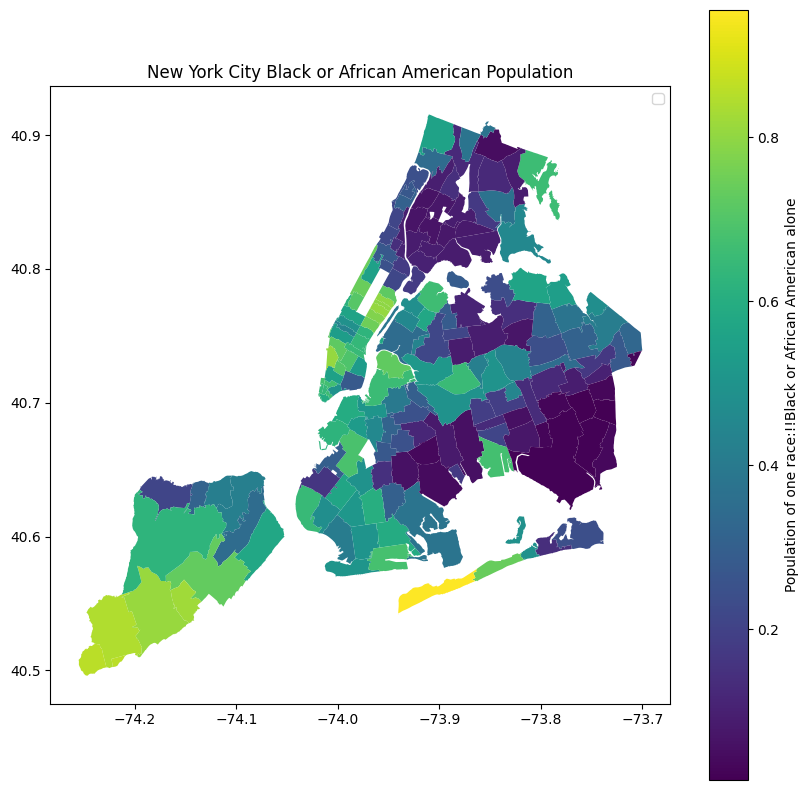

In [ ]:
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf_with_race[racial_group].min(), vmax=gdf_with_race[racial_group].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf_with_race.plot(ax=ax, column=racial_group, cmap=cmap, legend=True, legend_kwds={'label': "Population of one race:!!Black or African American alone", 'orientation': "vertical"})

ax.set_title("New York City Percent of White Population by ZIP Codes")
ax.legend()

plt.show()

/var/folders/mc/pwtbg_1x0bq90w0qhn4rxs1h0000gn/T/ipykernel_15356/199616884.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


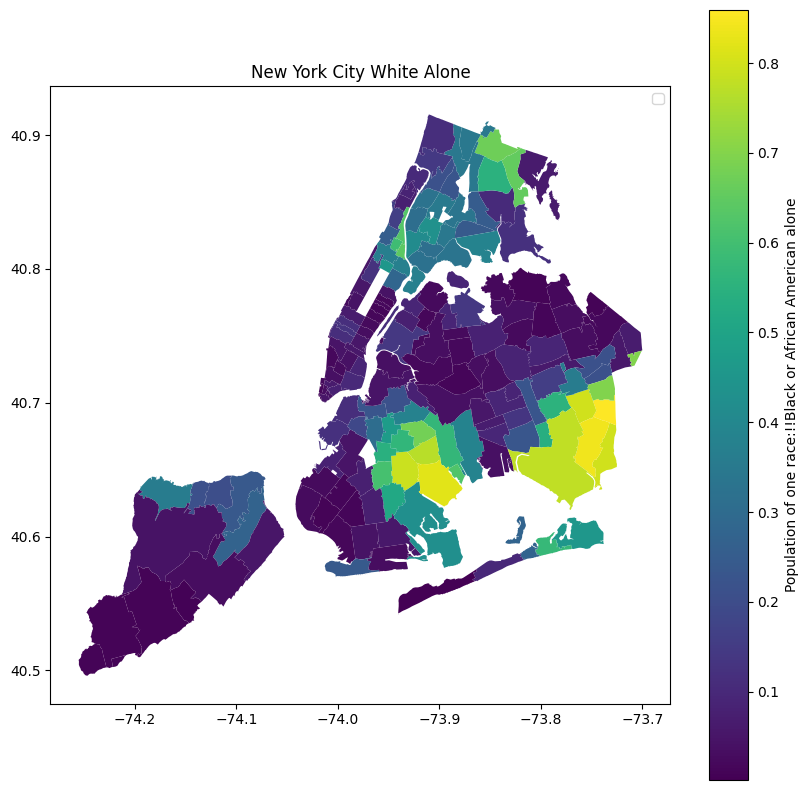

In [ ]:
racial_group = 'perc_black'
gdf_with_race = gdf.merge(df[['ZIP Code', racial_group]], left_on='label', right_on='ZIP Code', how='left')

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=gdf_with_race[racial_group].min(), vmax=gdf_with_race[racial_group].max())

fig, ax = plt.subplots(figsize=(10, 10))

gdf_with_race.plot(ax=ax, column=racial_group, cmap=cmap, legend=True, legend_kwds={'label': "Population of one race:!!Black or African American alone", 'orientation': "vertical"})

ax.set_title("New York City Percent of Black Population by ZIP Codes")
ax.legend()


plt.show()